<a href="https://colab.research.google.com/github/pearl-yu/mist5400spring2026/blob/main/neural_networks/basic_neural_networks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Basic Neural Networks

MIST 5400 Spring 2026
By: Pearl Yu

Creadit to the help from Aditya Deshpande and Chris Volinsky.

 Lets see if Neural Nets can improve on our models on the DirectMarketing data set...

In [ ]:
#Loading Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelBinarizer

#Installing data

[You can download the data here](https://drive.google.com/uc?export=download&id=1deEx-Ey37F7qznPlIqmaAjjkmkvBtV28).  Each record represents an individual who was targeted with a direct marketing offer.  The offer was a solicitation to make a charitable donation. You'll remember this data set from last chapter!


After downloading, we could open the folder at the left, and drag the downloaded local csv to the current working directory.


In [ ]:
df = pd.read_csv("DirectMarketing.csv")
# remove cases where Firstdate == 0 using .loc
df = df.loc[df.Firstdate != 0]


Below is just some data cleaning procedures. Maybe try asking Gemini to explain these?

In [ ]:
# replace gavr and glast with log versions of same features using .loc
df_clean = df
df_clean['gavr'] = np.log(df.gavr+1)
df_clean['glast'] = np.log(df.glast+1)
income_cat = pd.Categorical(df['Income'], categories=[0,1,2,3,4,5,6,7])
df_clean['Income'] = income_cat

rfaf2_cat = pd.Categorical(df['rfaf2'], categories=[1,2,3,4])
df_clean['rfaf2'] = rfaf2_cat

df_clean = pd.get_dummies(df_clean, columns=['rfaa2', 'pepstrfl','Income','rfaf2'],drop_first=True)
df_clean.head()
# Create a new feature 'tenure'
df_clean['tenure'] = df_clean['Lastdate'] - df_clean['Firstdate']

# maybe check to see this is always greater than zero?
df_clean['tenure'].min()
today = df_clean['Lastdate'].max()
df_clean['recency'] = today - df_clean['Lastdate']

# remove Firstdate and Lastdate
df_clean = df_clean.drop(['Firstdate', 'Lastdate'], axis=1)


In [ ]:
# Take a look at a few rows
df_clean.head()


,Amount,glast,gavr,class,rfaa2_E,rfaa2_F,rfaa2_G,pepstrfl_X,Income_1,Income_2,Income_3,Income_4,Income_5,Income_6,Income_7,rfaf2_2,rfaf2_3,rfaf2_4,tenure,recency
0,0.06,3.931826,3.433987,0,False,False,True,False,False,False,True,False,False,False,False,False,False,False,100,193
1,0.16,3.044522,3.070376,1,False,False,True,True,False,True,False,False,False,False,False,False,False,True,401,100
2,0.20,1.791759,2.277267,0,True,False,False,False,False,False,False,False,False,False,False,False,False,True,93,99
3,0.13,3.258097,3.157000,0,False,False,True,False,False,False,False,False,False,True,False,True,False,False,194,99
4,0.10,3.258097,2.602690,0,False,False,True,False,False,False,False,False,False,False,False,False,False,False,201,191


# Let's review Logistic Regression a little

In [ ]:
#Loading Libraries
from sklearn import metrics
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

In [ ]:
X = df_clean.drop(['class'], axis=1)
y = df_clean['class']

In [ ]:
#Split Data into Testing and Training Data
# original random_state = 42 gives results *81, 78, 85)
random_state_value = 99
X_train,X_test, y_train,y_test = train_test_split(X,y,test_size = 0.2,random_state = random_state_value)

In [ ]:
lrmodel = LogisticRegression(solver="liblinear")
lrmodel.fit(X_train,y_train)

LogisticRegression(solver='liblinear')

In [ ]:
from sklearn.metrics import accuracy_score

# Define a range of thresholds to test
thresholds = np.arange(0, 1.01, 0.05)

train_accuracies = []
test_accuracies = []

# Get predicted probabilities for the training set
y_prob_lr_train = lrmodel.predict_proba(X_train)[:, 1]
# Get predicted probabilities for the testing set
y_prob_lr_test = lrmodel.predict_proba(X_test)[:, 1]

for threshold in thresholds:
    # Calculate accuracy for training set
    y_pred_train_threshold = (y_prob_lr_train >= threshold).astype(int)
    train_accuracy = accuracy_score(y_train, y_pred_train_threshold)
    train_accuracies.append(train_accuracy)

    # Calculate accuracy for testing set
    y_pred_test_threshold = (y_prob_lr_test >= threshold).astype(int)
    test_accuracy = accuracy_score(y_test, y_pred_test_threshold)
    test_accuracies.append(test_accuracy)

# Find the best threshold and highest accuracy for the Keras model on the testing set
best_threshold_lr = thresholds[np.argmax(test_accuracies)]
highest_accuracy_lr = np.max(test_accuracies)

print(f"Best Threshold: {best_threshold_lr:.2f}")
print(f"Highest Testing Accuracy: {highest_accuracy_lr :.4f}")

Best Threshold: 0.20
Highest Testing Accuracy: 0.9477


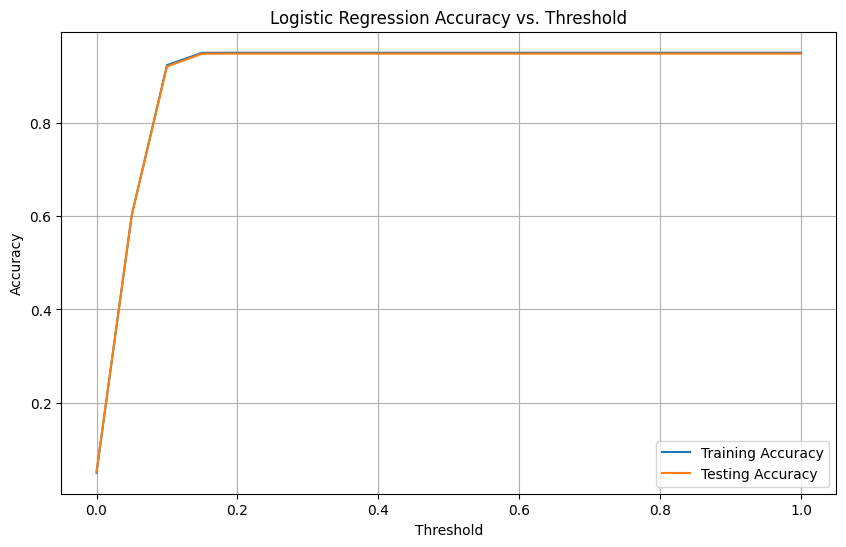

In [ ]:
# Plot the accuracies
plt.figure(figsize=(10, 6))
plt.plot(thresholds, train_accuracies, label='Training Accuracy')
plt.plot(thresholds, test_accuracies, label='Testing Accuracy')
plt.xlabel('Threshold')
plt.ylabel('Accuracy')
plt.title('Logistic Regression Accuracy vs. Threshold')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# What's the baseline classifications?

# Calculate the proportion of the majority class in the target variable y
baseline_accuracy = y.value_counts(normalize=True).max()

print(f"Baseline Classification Accuracy (predicting the majority class): {baseline_accuracy:.4f}")

Baseline Classification Accuracy (predicting the majority class): 0.9493


The accuracy is so high, well because the the propotion of people who aren't donors is really large. As we mentioned in class, with such an imbalance baseline, you'll get a high accuracy score if just classify everyone as a non-donar. Accuracy can be a misleading metric.

Instead, I asked Gemini what metrics I should look at. This is the answer:

> **Precision:** This tells you, out of all the instances your model predicted as positive, how many actually were positive. It answers: "When it predicts a positive, how often is it correct?"

In [ ]:
from sklearn.metrics import precision_score, recall_score

# --- Logistic Regression Precision ---
# Get predictions using the best threshold for Logistic Regression
y_pred_lr_test_best_threshold = (y_prob_lr_test >= best_threshold_lr).astype(int)
precision_lr = precision_score(y_test, y_pred_lr_test_best_threshold, zero_division=0)

print("Evaluation Metrics (Test Set):")
print("--------------------------------")
print(f"Logistic Regression Precision: {precision_lr:.4f}")

Evaluation Metrics (Test Set):
--------------------------------
Logistic Regression Precision: 0.0000
Logistic Regression Recall: 0.0000


Precision = 0.0000: This indicates that for the best_threshold_lr you found (which was 0.20), your logistic regression model did not predict any instances as positive (i.e., did not predict any potential donors) in the test set.

Because no positive predictions were made, there were no true positives and no false positives, making the precision undefined, which zero_division=0 handles by setting it to zero. In simple terms, when the model was asked to identify a donor, it never did, or any time it did, it was wrong. In this specific case, it's that it never identified any donors at that threshold.

In [ ]:
from sklearn.metrics import precision_score
import numpy as np # Ensure numpy is imported

# Define a range of thresholds to test
thresholds = np.arange(0, 1.01, 0.05)

train_precisions = []
test_precisions = []

# Get predicted probabilities for the training set
y_prob_lr_train = lrmodel.predict_proba(X_train)[:, 1]
# Get predicted probabilities for the testing set
y_prob_lr_test = lrmodel.predict_proba(X_test)[:, 1]

for threshold in thresholds:
    # Calculate precision for training set
    y_pred_train_threshold = (y_prob_lr_train >= threshold).astype(int)
    train_precision = precision_score(y_train, y_pred_train_threshold, zero_division=0)
    train_precisions.append(train_precision)

    # Calculate precision for testing set
    y_pred_test_threshold = (y_prob_lr_test >= threshold).astype(int)
    test_precision = precision_score(y_test, y_pred_test_threshold, zero_division=0)
    test_precisions.append(test_precision)

# Find the best threshold and highest precision on the testing set
best_threshold_lr_precision = thresholds[np.argmax(test_precisions)]
highest_precision_lr = np.max(test_precisions)

print(f"Best Threshold for Precision: {best_threshold_lr_precision:.2f}")
print(f"Highest Testing Precision: {highest_precision_lr :.4f}")

Best Threshold for Precision: 0.15
Highest Testing Precision: 0.2857


## Neural Networks (using Keras)

In [ ]:
#Loading Libraries

import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
# Defining SIMPLE Keras Model
kmodel = Sequential()
kmodel.add(Dense(12,input_shape =(19,), activation = "relu"))
kmodel.add(Dense(8,activation = "relu"))
kmodel.add(Dense(1,activation = "sigmoid"))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
#Compile Keras Model
kmodel.compile(loss = "binary_crossentropy", optimizer = "adam")


In [ ]:
#Fitting Keras Model
kmodel.fit(X_train_scaled,y_train,epochs = 50, batch_size = 256)

Epoch 1/50
600/600 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9492 - loss: 0.1954
Epoch 2/50
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9499 - loss: 0.1936
Epoch 3/50
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9499 - loss: 0.1935
Epoch 4/50
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9498 - loss: 0.1935
Epoch 5/50
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9496 - loss: 0.1940
Epoch 6/50
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9498 - loss: 0.1938
Epoch 7/50
600/600 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9502 - loss: 0.1927
Epoch 8/50
600/600 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9501 - loss: 0.1931
Epoch 9/50
600/600 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9501 - loss: 0.1932
Epoch 10/50
600/600 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9495 - loss: 0.1946
Epoch 11/50
600/600 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9496 - loss: 0.1942
Epoch 12/50
600/600 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

In [ ]:
kmodel.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 12)             │           240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,061 (4.15 KB)

 Trainable params: 353 (1.38 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 708 (2.77 KB)

In [ ]:
from sklearn.metrics import precision_score

# Get predicted probabilities for the positive class (class 1)
y_prob_keras_test = kmodel.predict(X_test_scaled).ravel()
y_prob_keras_train = kmodel.predict(X_train_scaled).ravel()

# Define a range of thresholds to test
thresholds = np.arange(0, 1.01, 0.05)

train_precisions_keras = []
test_precisions_keras = []

for threshold in thresholds:
    # Calculate precision for training set
    y_pred_train_threshold_keras = (y_prob_keras_train >= threshold).astype(int)
    train_precision_keras = precision_score(y_train, y_pred_train_threshold_keras, zero_division=0)
    train_precisions_keras.append(train_precision_keras)

    # Calculate precision for testing set
    y_pred_test_threshold_keras = (y_prob_keras_test >= threshold).astype(int)
    test_precision_keras = precision_score(y_test, y_pred_test_threshold_keras, zero_division=0)
    test_precisions_keras.append(test_precision_keras)

# Find the best threshold and highest precision for the Keras model on the testing set
best_threshold_keras_precision = thresholds[np.argmax(test_precisions_keras)]
highest_precision_keras = np.max(test_precisions_keras)

print(f"Keras Model (Simple) - Best Threshold for Precision: {best_threshold_keras_precision:.2f}")
print(f"Keras Model (Simple) - Highest Testing Precision: {highest_precision_keras:.4f}")

1199/1199 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step
4795/4795 ━━━━━━━━━━━━━━━━━━━━ 7s 1ms/step
Keras Model (Simple) - Best Threshold for Precision: 0.50
Keras Model (Simple) - Highest Testing Precision: 1.0000


# Adding another layer & dropout

In [ ]:
## Now we make it more complex, with an extra layer, and Dropout

kmodel2 = Sequential()
kmodel2.add(Dense(12,input_shape =(19,), activation = "relu")) # Change input_shape to (19,)
kmodel2.add(Dropout(0.3))  # Add dropout
kmodel2.add(Dense(8,activation = "relu"))
kmodel2.add(Dropout(0.3))  # Add dropout to the new layer
kmodel2.add(Dense(6,activation = "relu"))
kmodel2.add(Dense(1,activation = "sigmoid"))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
#Compile Keras Model
kmodel2.compile(loss = "binary_crossentropy", optimizer = "adam", metrics =['accuracy'])


In [ ]:
#Fitting Keras Model
kmodel2.fit(X_train_scaled,y_train,epochs = 50, batch_size = 256)

Epoch 1/50
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9495 - loss: 0.1961
Epoch 2/50
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9488 - loss: 0.1982
Epoch 3/50
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9496 - loss: 0.1963
Epoch 4/50
600/600 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9497 - loss: 0.1958
Epoch 5/50
600/600 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9497 - loss: 0.1953
Epoch 6/50
600/600 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9501 - loss: 0.1944
Epoch 7/50
600/600 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9496 - loss: 0.1961
Epoch 8/50
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9510 - loss: 0.1914
Epoch 9/50
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9505 - loss: 0.1932
Epoch 10/50
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9502 - loss: 0.1938
Epoch 11/50
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9510 - loss: 0.1919
Epoch 12/50
600/600 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

In [ ]:
from sklearn.metrics import precision_score

# Get predicted probabilities for the positive class (class 1)
y_prob_keras_test = kmodel2.predict(X_test_scaled).ravel()
y_prob_keras_train = kmodel2.predict(X_train_scaled).ravel()

# Define a range of thresholds to test
thresholds = np.arange(0, 1.01, 0.05)

train_precisions_keras2 = []
test_precisions_keras2 = []

for threshold in thresholds:
    # Calculate precision for training set
    y_pred_train_threshold_keras = (y_prob_keras_train >= threshold).astype(int)
    train_precision_keras = precision_score(y_train, y_pred_train_threshold_keras, zero_division=0)
    train_precisions_keras2.append(train_precision_keras)

    # Calculate precision for testing set
    y_pred_test_threshold_keras = (y_prob_keras_test >= threshold).astype(int)
    test_precision_keras = precision_score(y_test, y_pred_test_threshold_keras, zero_division=0)
    test_precisions_keras2.append(test_precision_keras)

# Find the best threshold and highest precision for the Keras model on the testing set
best_threshold_keras2_precision = thresholds[np.argmax(test_precisions_keras2)]
highest_precision_keras2 = np.max(test_precisions_keras2)

print(f"Keras Model (Complex) - Best Threshold for Precision: {best_threshold_keras2_precision:.2f}")
print(f"Keras Model (Complex) - Highest Testing Precision: {highest_precision_keras2:.4f}")

1199/1199 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
4795/4795 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step
Keras Model (Complex) - Best Threshold for Precision: 0.10
Keras Model (Complex) - Highest Testing Precision: 0.1097


In [ ]:
kmodel.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 12)             │           240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,061 (4.15 KB)

 Trainable params: 353 (1.38 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 708 (2.77 KB)

# Comparing results

In [ ]:
print("Model Performance Comparison:")
print("-" * 30)
print(f"Logistic Regression:")
print(f"  Highest Testing Precision: {highest_precision_lr:.4f}")
print(f"  Best Threshold: {best_threshold_lr:.2f}")
print("-" * 30)
print(f"Simple Keras Model:")
print(f"  Highest Testing Precision: {highest_precision_keras:.4f}")
print(f"  Best Threshold: {best_threshold_keras_precision:.2f}")
print("-" * 30)
print(f"More Complex Keras Model (with Dropout):")
print(f"  Highest Testing Precision: {highest_precision_keras2:.4f}")
print(f"  Best Threshold: {best_threshold_keras2_precision:.2f}")
print("-" * 30)

Model Performance Comparison:
------------------------------
Logistic Regression:
  Highest Testing Precision: 0.2857
  Best Threshold: 0.20
------------------------------
Simple Keras Model:
  Highest Testing Precision: 1.0000
  Best Threshold: 0.50
------------------------------
More Complex Keras Model (with Dropout):
  Highest Testing Precision: 0.1097
  Best Threshold: 0.10
------------------------------
